In [ ]:
"""
This notebook implements a CNN model for histopathologic cancer detection.
It loads the full dataset available in the Kaggle environment, applies standard preprocessing
and augmentation, and trains a compact CNN model with PyTorch. The notebook automatically
uses the GPU if available and plots training and validation accuracy over epochs.
"""

import os
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

data_dir = "/kaggle/input/histopathologic-cancer-detection"
train_images_dir = os.path.join(data_dir, "train")
df = pd.read_csv(os.path.join(data_dir, "train_labels.csv"))
df["path"] = df["id"].apply(lambda x: os.path.join(train_images_dir, f"{x}.tif"))

class HistopathologyDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.loc[idx, "path"]
        label = self.data.loc[idx, "label"]
        image = Image.open(img_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label

transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_df, val_df = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)

train_dataset = HistopathologyDataset(train_df, transform=transform)
val_dataset = HistopathologyDataset(val_df, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False, num_workers=2)

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        with torch.no_grad():
            dummy = torch.zeros(1, 3, 64, 64)
            dummy_out = self.features(dummy)
            flat_size = dummy_out.view(1, -1).shape[1]
            print(f"Flattened feature size: {flat_size}")

        self.classifier = nn.Sequential(
            nn.Linear(flat_size, 64),
            nn.ReLU(),
            nn.Linear(64, 2)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        x = self.classifier(x)
        return x

model = SimpleCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    model.train()
    correct_train = 0
    total_train = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        _, preds = torch.max(outputs, 1)
        correct_train += (preds == labels).sum().item()
        total_train += labels.size(0)

    train_acc = correct_train / total_train
    train_accuracies.append(train_acc)

    model.eval()
    correct_val = 0
    total_val = 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct_val += (preds == labels).sum().item()
            total_val += labels.size(0)

    val_acc = correct_val / total_val
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] | Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f}")

plt.figure(figsize=(8, 5))
plt.plot(range(1, num_epochs+1), train_accuracies, label="Train Accuracy")
plt.plot(range(1, num_epochs+1), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

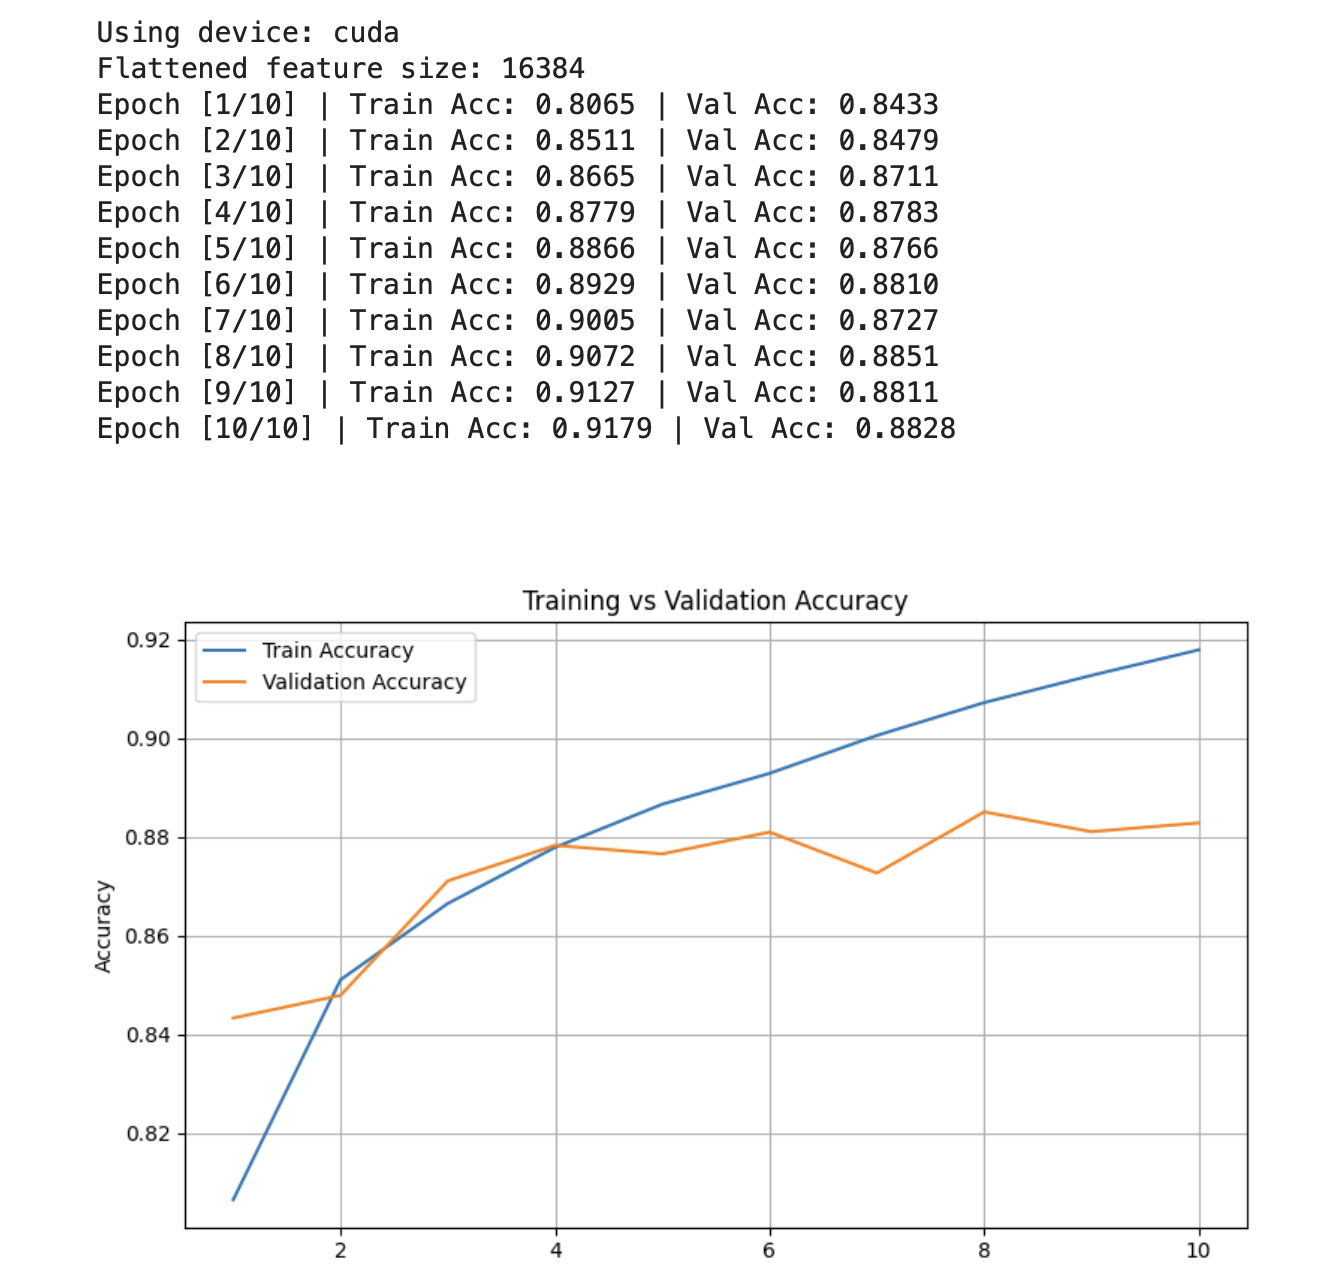

In [3]:
"""
This block is included because the notebook was ran in Kaggle's environment to utilize their GPUs. When uploading to github, the repo was too large
due to the data size so I removed the data. As such this notebook is not capable of running, but the results are still visible, and below
is the plot I created to show the accuracy of the training vs validation steps.
"""

from IPython.display import Image
from IPython.core.display import HTML 

PATH = "../images/"
Image(filename = PATH + "accuracy.png", width=1000, height=1000)

In [ ]:
"""
This final cell generates predictions on the test dataset using the trained CNN model.
It prepares the test image paths, applies the same preprocessing transforms used during training,
runs the model in evaluation mode to avoid gradient calculations, and stores the predicted labels
for submission. The predictions are then written to a CSV file in the required Kaggle format, ready
to be uploaded to the competition leaderboard.
"""

import glob
from tqdm import tqdm

test_dir = os.path.join(data_dir, "test")
test_image_paths = glob.glob(os.path.join(test_dir, "*.tif"))

test_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

class TestDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        path = self.image_paths[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        img_id = os.path.basename(path).replace(".tif", "")
        return image, img_id

test_dataset = TestDataset(test_image_paths, transform=test_transform)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

model.eval()
predictions = []

with torch.no_grad():
    for images, img_ids in tqdm(test_loader):
        images = images.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        preds = preds.cpu().numpy()
        for img_id, pred in zip(img_ids, preds):
            predictions.append((img_id, pred))

submission_df = pd.DataFrame(predictions, columns=["id", "label"])
submission_df.to_csv("/kaggle/working/submission.csv", index=False)
print("/kaggle/working/submission.csv")